# Logistic Regression

Import everything that we need for this project.

In [1]:
# data analysis, splitting and wrangling
import pandas as pd
import numpy as np

# visualization
import matplotlib.pyplot as plt
%matplotlib inline

## 1. Heart Disease Dataset. 

This database contains 76 attributes, but all published experiments refer to using a subset of 14 of them. In particular, the Cleveland database is the only one that has been used by ML researchers to this date. The "goal" field refers to the presence of heart disease in the patient. It is integer valued from 0 (no presence) to 4. Experiments with the Cleveland database have concentrated on simply attempting to distinguish presence (values 1,2,3,4) from absence (value 0).  

The names and social security numbers of the patients were recently removed from the database, replaced with dummy values.

### Attribute Information:

- age - age in years (Ratio Variable, Continuous)
- sex - sex(1 = male; 0 = female) (Nominal, Binary)
- chest_pain - chest pain type (1 = typical angina; 2 = atypical angina; 3 = non-anginal pain; 4 = asymptomatic) (Ordinal, Discrete)
- blood_pressure - resting blood pressure (in mm Hg on admission to the hospital) (Ratio Variable, Continuous)
- serum_cholestoral - serum cholestoral in mg/dl (Ratio Variable, Continuous)
- fasting_blood_sugar - fasting blood sugar > 120 mg/dl (1 = true; 0 = false) (Nominal or Ordinal?, Binary)
- electrocardiographic - resting electrocardiographic results (0 = normal; 1 = having ST-T; 2 = hypertrophy) (Ordinal, Discrete)
- max_heart_rate - maximum heart rate achieved (Ratio Variable, Continuous)
- induced_angina - exercise induced angina (1 = yes; 0 = no) (Nominal, Binary)
- ST_depression - ST depression induced by exercise relative to rest (Ratio Variable, Continuous)
- slope - the slope of the peak exercise ST segment (1 = upsloping; 2 = flat; 3 = downsloping) (Nominal, Discrete)
- no_of_vessels - number of major vessels (0-3) colored by flourosopy (Nominal or Ordinal, Discrete)
- thal - 3 = normal; 6 = fixed defect; 7 = reversable defect (Nominal, Discrete)
- diagnosis - the predicted attribute - diagnosis of heart disease (angiographic disease status) (Value 0 = < 50% diameter narrowing; Value 1 = > 50% diameter narrowing) (Discrete label)

In [2]:
# column names in accordance with feature information
col_names = ['age','sex','chest_pain','blood_pressure','serum_cholestoral','fasting_blood_sugar', 'electrocardiographic',
             'max_heart_rate','induced_angina','ST_depression','slope','no_of_vessels','thal','diagnosis']

# read the file
df = pd.read_csv("http://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data", names=col_names, header=None, na_values="?")

print("Number of records: {}\nNumber of variables: {}".format(df.shape[0], df.shape[1]))

# display the first 5 lines
df.head(10)

Number of records: 303
Number of variables: 14


,age,sex,chest_pain,blood_pressure,serum_cholestoral,fasting_blood_sugar,electrocardiographic,max_heart_rate,induced_angina,ST_depression,slope,no_of_vessels,thal,diagnosis
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0
5,56.0,1.0,2.0,120.0,236.0,0.0,0.0,178.0,0.0,0.8,1.0,0.0,3.0,0
6,62.0,0.0,4.0,140.0,268.0,0.0,2.0,160.0,0.0,3.6,3.0,2.0,3.0,3
7,57.0,0.0,4.0,120.0,354.0,0.0,0.0,163.0,1.0,0.6,1.0,0.0,3.0,0
8,63.0,1.0,4.0,130.0,254.0,0.0,2.0,147.0,0.0,1.4,2.0,1.0,7.0,2
9,53.0,1.0,4.0,140.0,203.0,1.0,2.0,155.0,1.0,3.1,3.0,0.0,7.0,1


## 2. Try converting the problem into a binary classification problem

### Target value

In [3]:
# count values of explained variable
df.diagnosis.value_counts()

0    164
1     55
2     36
3     35
4     13
Name: diagnosis, dtype: int64

In [4]:
# create a boolean vector and map it with corresponding values (True=1, False=0)
df.diagnosis = (df.diagnosis != 0).astype(int)
df.diagnosis.value_counts()

0    164
1    139
Name: diagnosis, dtype: int64

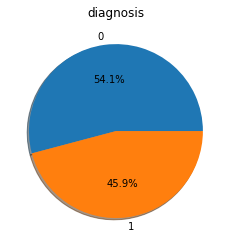

In [5]:
# create plot
f, ax = plt.subplots()
df['diagnosis'].value_counts().plot.pie(autopct='%1.1f%%', ax=ax, shadow=True)
ax.set_title('diagnosis')
ax.set_ylabel('')
plt.show()

### Try printing the dataset again

Look at the binary label that remains.

In [6]:
df.head(10)

,age,sex,chest_pain,blood_pressure,serum_cholestoral,fasting_blood_sugar,electrocardiographic,max_heart_rate,induced_angina,ST_depression,slope,no_of_vessels,thal,diagnosis
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0
5,56.0,1.0,2.0,120.0,236.0,0.0,0.0,178.0,0.0,0.8,1.0,0.0,3.0,0
6,62.0,0.0,4.0,140.0,268.0,0.0,2.0,160.0,0.0,3.6,3.0,2.0,3.0,1
7,57.0,0.0,4.0,120.0,354.0,0.0,0.0,163.0,1.0,0.6,1.0,0.0,3.0,0
8,63.0,1.0,4.0,130.0,254.0,0.0,2.0,147.0,0.0,1.4,2.0,1.0,7.0,1
9,53.0,1.0,4.0,140.0,203.0,1.0,2.0,155.0,1.0,3.1,3.0,0.0,7.0,1


## 3. Normalize the dataset

In [7]:
from sklearn import preprocessing

X, Y = df.iloc[:, :-1], df.iloc[:, -1]

print(X)
print(Y)

# see if there are missing entries in the dataset features
X.isnull().sum()



      age  sex  chest_pain  blood_pressure  serum_cholestoral  \
0    63.0  1.0         1.0           145.0              233.0   
1    67.0  1.0         4.0           160.0              286.0   
2    67.0  1.0         4.0           120.0              229.0   
3    37.0  1.0         3.0           130.0              250.0   
4    41.0  0.0         2.0           130.0              204.0   
5    56.0  1.0         2.0           120.0              236.0   
6    62.0  0.0         4.0           140.0              268.0   
7    57.0  0.0         4.0           120.0              354.0   
8    63.0  1.0         4.0           130.0              254.0   
9    53.0  1.0         4.0           140.0              203.0   
10   57.0  1.0         4.0           140.0              192.0   
11   56.0  0.0         2.0           140.0              294.0   
12   56.0  1.0         3.0           130.0              256.0   
13   44.0  1.0         2.0           120.0              263.0   
14   52.0  1.0         3.

age                     0
sex                     0
chest_pain              0
blood_pressure          0
serum_cholestoral       0
fasting_blood_sugar     0
electrocardiographic    0
max_heart_rate          0
induced_angina          0
ST_depression           0
slope                   0
no_of_vessels           4
thal                    2
dtype: int64

In [8]:
# fill missing values with mode 
X['no_of_vessels'].fillna(X['no_of_vessels'].mode()[0], inplace=True) 
X['thal'].fillna(X['thal'].mode()[0], inplace=True)

#do minmax normalization
x = X.values #returns a numpy array
min_max_scaler = preprocessing.MinMaxScaler()#other kinds of normalization possible
x_scaled = min_max_scaler.fit_transform(x)
X_scaled = pd.DataFrame(x_scaled, columns=col_names[:-1])

final_dataset = pd.concat([X_scaled, Y], axis=1, sort=False)
print(final_dataset)

# see if there are missing entries in the dataset features
final_dataset.isnull().sum()

          age  sex  chest_pain  blood_pressure  serum_cholestoral  \
0    0.708333  1.0    0.000000        0.481132           0.244292   
1    0.791667  1.0    1.000000        0.622642           0.365297   
2    0.791667  1.0    1.000000        0.245283           0.235160   
3    0.166667  1.0    0.666667        0.339623           0.283105   
4    0.250000  0.0    0.333333        0.339623           0.178082   
5    0.562500  1.0    0.333333        0.245283           0.251142   
6    0.687500  0.0    1.000000        0.433962           0.324201   
7    0.583333  0.0    1.000000        0.245283           0.520548   
8    0.708333  1.0    1.000000        0.339623           0.292237   
9    0.500000  1.0    1.000000        0.433962           0.175799   
10   0.583333  1.0    1.000000        0.433962           0.150685   
11   0.562500  0.0    0.333333        0.433962           0.383562   
12   0.562500  1.0    0.666667        0.339623           0.296804   
13   0.312500  1.0    0.333333    

age                     0
sex                     0
chest_pain              0
blood_pressure          0
serum_cholestoral       0
fasting_blood_sugar     0
electrocardiographic    0
max_heart_rate          0
induced_angina          0
ST_depression           0
slope                   0
no_of_vessels           0
thal                    0
diagnosis               0
dtype: int64

### Numeric features

In [9]:
# view of descriptive statistics
final_dataset[['serum_cholestoral', 'max_heart_rate', 'age', 'blood_pressure', 'ST_depression']].describe()

,serum_cholestoral,max_heart_rate,age,blood_pressure,ST_depression
count,303.000000,303.000000,303.000000,303.000000,303.000000
mean,0.275555,0.600055,0.529978,0.355564,0.167678
std,0.118212,0.174618,0.188305,0.166035,0.187270
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.194064,0.477099,0.395833,0.245283,0.000000
50%,0.262557,0.625954,0.562500,0.339623,0.129032
75%,0.340183,0.725191,0.666667,0.433962,0.258065
max,1.000000,1.000000,1.000000,1.000000,1.000000


### Categorical features

In [10]:
# count ill vs healthy people grouped by sex
df.groupby(['sex','diagnosis'])['diagnosis'].count()

sex  diagnosis
0.0  0             72
     1             25
1.0  0             92
     1            114
Name: diagnosis, dtype: int64

## Again, let's start with just two features and try out logistic regression.

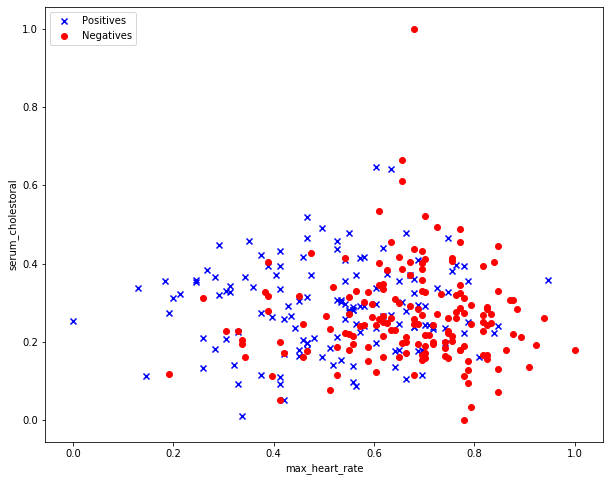

In [11]:
X_1=final_dataset['max_heart_rate']
X_2=final_dataset['serum_cholestoral']
Y=final_dataset['diagnosis']


####let's try visualizing the dataset
positive_diagnoses =  final_dataset['diagnosis']==1
negative_diagnoses =  final_dataset['diagnosis']==0

positives = final_dataset[positive_diagnoses]
negatives = final_dataset[negative_diagnoses]

plt.figure(figsize=(10,8))
plt.scatter(positives['max_heart_rate'], positives['serum_cholestoral'],color='blue',marker='x', label='Positives')
plt.scatter(negatives['max_heart_rate'], negatives['serum_cholestoral'],color='red',marker='o', label='Negatives')
plt.legend(loc="upper left")
plt.ylabel('serum_cholestoral')
plt.xlabel('max_heart_rate')
plt.show()

## Train logistic regression model

In [12]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(random_state=0)
print(model)

X_twofeat = pd.concat([X_1, X_2], axis=1, sort=False)

model.fit(X_twofeat.to_numpy() , Y)

###if you want to see the probabilities returned by Logistic Regression
Y_probs = model.predict_proba(X_twofeat.to_numpy())

###if you are fine with using a threshold probability of 0.5
Y_predicted = model.predict(X_twofeat.to_numpy())

print(Y_probs.shape)


final_dataset['Predicted_Prob'] = Y_probs[:,1]##second class probability is just one minus this value
final_dataset['Predictions'] = Y_predicted
final_dataset.head(15)

LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
                   intercept_scaling=1, l1_ratio=None, max_iter=100,
                   multi_class='warn', n_jobs=None, penalty='l2',
                   random_state=0, solver='warn', tol=0.0001, verbose=0,
                   warm_start=False)
(303, 2)


/Users/auy212-admin/anaconda3/lib/python3.7/site-packages/sklearn/linear_model/logistic.py:432: FutureWarning: Default solver will be changed to 'lbfgs' in 0.22. Specify a solver to silence this warning.
  FutureWarning)


,age,sex,chest_pain,blood_pressure,serum_cholestoral,fasting_blood_sugar,electrocardiographic,max_heart_rate,induced_angina,ST_depression,slope,no_of_vessels,thal,diagnosis,Predicted_Prob,Predictions
0,0.708333,1.0,0.000000,0.481132,0.244292,1.0,1.0,0.603053,0.0,0.370968,1.0,0.000000,0.75,0,0.442002,0
1,0.791667,1.0,1.000000,0.622642,0.365297,0.0,1.0,0.282443,1.0,0.241935,0.5,1.000000,0.00,1,0.713378,1
2,0.791667,1.0,1.000000,0.245283,0.235160,0.0,1.0,0.442748,1.0,0.419355,0.5,0.666667,1.00,1,0.567633,1
3,0.166667,1.0,0.666667,0.339623,0.283105,0.0,0.0,0.885496,0.0,0.564516,1.0,0.000000,0.00,0,0.249496,0
4,0.250000,0.0,0.333333,0.339623,0.178082,0.0,1.0,0.770992,0.0,0.225806,0.0,0.000000,0.00,0,0.302489,0
5,0.562500,1.0,0.333333,0.245283,0.251142,0.0,0.0,0.816794,0.0,0.129032,0.0,0.000000,0.00,0,0.286623,0
6,0.687500,0.0,1.000000,0.433962,0.324201,0.0,1.0,0.679389,0.0,0.580645,1.0,0.666667,0.00,1,0.401141,0
7,0.583333,0.0,1.000000,0.245283,0.520548,0.0,0.0,0.702290,1.0,0.096774,0.0,0.000000,0.00,0,0.429311,0
8,0.708333,1.0,1.000000,0.339623,0.292237,0.0,1.0,0.580153,0.0,0.225806,0.5,0.333333,1.00,1,0.471696,0
9,0.500000,1.0,1.000000,0.433962,0.175799,1.0,1.0,0.641221,1.0,0.500000,1.0,0.000000,1.00,1,0.396149,0


## Let's look at the learnt decision boundary

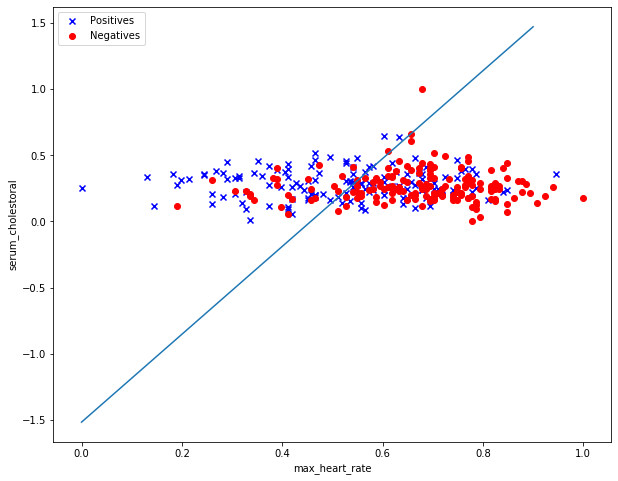

In [13]:
####let's try visualizing the dataset
positive_diagnoses =  final_dataset['diagnosis']==1
negative_diagnoses =  final_dataset['diagnosis']==0

positives = final_dataset[positive_diagnoses]
negatives = final_dataset[negative_diagnoses]

##plot positives and negatives
plt.figure(figsize=(10,8))
plt.scatter(positives['max_heart_rate'], positives['serum_cholestoral'],color='blue',marker='x', label='Positives')
plt.scatter(negatives['max_heart_rate'], negatives['serum_cholestoral'],color='red',marker='o', label='Negatives')
plt.legend(loc="upper left")
plt.ylabel('serum_cholestoral')
plt.xlabel('max_heart_rate')

#plot decision boundary
points_x=[x/10. for x in range(10)]
line_bias = model.intercept_
line_w = model.coef_.T
points_y=[(line_w[0]*x+line_bias)/(-1*line_w[1]) for x in points_x]
plt.plot(points_x, points_y)

plt.show()

## Adding all the features. Logistic Regression

In [15]:
X = final_dataset.loc[:,final_dataset.columns!='diagnosis']
Y = final_dataset['diagnosis']

print(type(X))
print(type(Y))

from sklearn.linear_model import LogisticRegression

##choose model hyperparams
model = LogisticRegression(random_state=0)
print(model)

model.fit(X,Y)

print("Learnt model is ==> Coefficients: "+str(model.coef_)+" Intercept: "+str(model.intercept_))

Y_predicted = model.predict(X)

final_dataset['Predictions'] = Y_predicted
final_dataset['Predicted_Prob'] = Y_probs[:,1]##second class probability is just one minus this value

final_dataset.head(15)

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.series.Series'>
LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
                   intercept_scaling=1, l1_ratio=None, max_iter=100,
                   multi_class='warn', n_jobs=None, penalty='l2',
                   random_state=0, solver='warn', tol=0.0001, verbose=0,
                   warm_start=False)
Learnt model is ==> Coefficients: [[-0.31902786  0.5285003   0.74010003  0.67430477  0.18978188 -0.31479986
   0.33307717 -1.72469614  0.70312199  0.79261474  0.61662667  1.82032291
   0.89694347 -0.29369409  1.11037804]] Intercept: [-1.88235201]


/Users/auy212-admin/anaconda3/lib/python3.7/site-packages/sklearn/linear_model/logistic.py:432: FutureWarning: Default solver will be changed to 'lbfgs' in 0.22. Specify a solver to silence this warning.
  FutureWarning)


,age,sex,chest_pain,blood_pressure,serum_cholestoral,fasting_blood_sugar,electrocardiographic,max_heart_rate,induced_angina,ST_depression,slope,no_of_vessels,thal,diagnosis,Predicted_Prob,Predictions
0,0.708333,1.0,0.000000,0.481132,0.244292,1.0,1.0,0.603053,0.0,0.370968,1.0,0.000000,0.75,0,0.442002,0
1,0.791667,1.0,1.000000,0.622642,0.365297,0.0,1.0,0.282443,1.0,0.241935,0.5,1.000000,0.00,1,0.713378,1
2,0.791667,1.0,1.000000,0.245283,0.235160,0.0,1.0,0.442748,1.0,0.419355,0.5,0.666667,1.00,1,0.567633,1
3,0.166667,1.0,0.666667,0.339623,0.283105,0.0,0.0,0.885496,0.0,0.564516,1.0,0.000000,0.00,0,0.249496,0
4,0.250000,0.0,0.333333,0.339623,0.178082,0.0,1.0,0.770992,0.0,0.225806,0.0,0.000000,0.00,0,0.302489,0
5,0.562500,1.0,0.333333,0.245283,0.251142,0.0,0.0,0.816794,0.0,0.129032,0.0,0.000000,0.00,0,0.286623,0
6,0.687500,0.0,1.000000,0.433962,0.324201,0.0,1.0,0.679389,0.0,0.580645,1.0,0.666667,0.00,1,0.401141,1
7,0.583333,0.0,1.000000,0.245283,0.520548,0.0,0.0,0.702290,1.0,0.096774,0.0,0.000000,0.00,0,0.429311,0
8,0.708333,1.0,1.000000,0.339623,0.292237,0.0,1.0,0.580153,0.0,0.225806,0.5,0.333333,1.00,1,0.471696,1
9,0.500000,1.0,1.000000,0.433962,0.175799,1.0,1.0,0.641221,1.0,0.500000,1.0,0.000000,1.00,1,0.396149,1


## How well did our logistic regression classifier do?

In [16]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(Y, Y_predicted))

[[146  18]
 [ 27 112]]


# Evaluation of Classifiers
How do you evaluate these classifiers? We now discuss these topics via example.

In [17]:
actual_predicted = pd.concat([final_dataset['diagnosis'], final_dataset['Predictions']], axis=1, sort=False)
print(actual_predicted)

     diagnosis  Predictions
0            0            0
1            1            1
2            1            1
3            0            0
4            0            0
5            0            0
6            1            1
7            0            0
8            1            1
9            1            1
10           0            0
11           0            0
12           1            1
13           0            0
14           0            0
15           0            0
16           1            0
17           0            0
18           0            0
19           0            0
20           0            0
21           0            0
22           1            0
23           1            1
24           1            1
25           0            0
26           0            0
27           0            0
28           0            0
29           1            1
..         ...          ...
273          0            0
274          1            0
275          0            0
276          0      

In [18]:
from sklearn.metrics import confusion_matrix

confusion = confusion_matrix(Y, Y_predicted)
print(confusion)

TP = confusion[1,1]
TN = confusion[0,0]
FP = confusion[0,1]
FN = confusion[1,0]

print("True positives: "+str(TP))
print("True negatives: "+str(TN))
print("False positives: "+str(FP))
print("False negatives: "+str(FN))

[[146  18]
 [ 27 112]]
True positives: 112
True negatives: 146
False positives: 18
False negatives: 27


### Classification Accuracy: Overall, how often is the classifier correct?

In [19]:
from sklearn.metrics import accuracy_score

print((TP + TN) / float(TP + TN + FP + FN))
print(accuracy_score(Y, Y_predicted))

0.8514851485148515
0.8514851485148515


### Classification Error: Overall, how often is the classifier incorrect? (Also called Misclassification rate)

In [20]:
from sklearn.metrics import accuracy_score


print((FP + FN) / float(TP + TN + FP + FN))
print(1 - accuracy_score(Y, Y_predicted))

0.1485148514851485
0.14851485148514854


 ### Recall: When the actual value is positive, how often is the prediction correct?

How "sensitive" is the classifier to detecting positive instances?
Also known as "True Positive Rate" or "Sensitivity"

In [21]:
from sklearn.metrics import recall_score

print(TP / float(TP + FN))
recall = recall_score(Y, Y_predicted)
print(recall)

0.8057553956834532
0.8057553956834532


### Precision: When a positive value is predicted, how often is the prediction correct?

How "precise" is the classifier when predicting positive instances?

In [22]:
from sklearn.metrics import precision_score

print(TP / float(TP + FP))
precision = precision_score(Y, Y_predicted)
print(precision)

0.8615384615384616
0.8615384615384616


### F1 Score

In [23]:
print((2*precision*recall)/ (precision+recall))

0.8327137546468402


### ROC Curve

In [24]:
actual_predicted = pd.concat([final_dataset['diagnosis'], final_dataset['Predictions'], final_dataset['Predicted_Prob']], axis=1, sort=False)
print(actual_predicted)

     diagnosis  Predictions  Predicted_Prob
0            0            0        0.442002
1            1            1        0.713378
2            1            1        0.567633
3            0            0        0.249496
4            0            0        0.302489
5            0            0        0.286623
6            1            1        0.401141
7            0            0        0.429311
8            1            1        0.471696
9            1            1        0.396149
10           0            0        0.431822
11           0            0        0.457087
12           1            1        0.503366
13           0            0        0.325204
14           0            0        0.353954
15           0            0        0.276128
16           1            0        0.335709
17           0            0        0.385893
18           0            0        0.532147
19           0            0        0.337515
20           0            0        0.466390
21           0            0     

### Let's try a new threshold. 0.442002

In [25]:
actual_predicted['Predicted_WithNewThreshold'] = (actual_predicted['Predicted_Prob']>0.442002).astype(int)
print(actual_predicted)

     diagnosis  Predictions  Predicted_Prob  Predicted_WithNewThreshold
0            0            0        0.442002                           0
1            1            1        0.713378                           1
2            1            1        0.567633                           1
3            0            0        0.249496                           0
4            0            0        0.302489                           0
5            0            0        0.286623                           0
6            1            1        0.401141                           0
7            0            0        0.429311                           0
8            1            1        0.471696                           1
9            1            1        0.396149                           0
10           0            0        0.431822                           0
11           0            0        0.457087                           1
12           1            1        0.503366                     

### Calculate TPR and FPR

In [26]:
from sklearn.metrics import confusion_matrix


confusion = confusion_matrix(Y, actual_predicted['Predicted_WithNewThreshold'].to_numpy())
TP = confusion[1, 1]
TN = confusion[0, 0]
FP = confusion[0, 1]
FN = confusion[1, 0]

print('True Positive Rate: ')
print(TP / float(TP + FN))

print('False Positive Rate: ')
print(FP / float(TN + FP))

True Positive Rate: 
0.6834532374100719
False Positive Rate: 
0.3170731707317073


### Draw ROC Curve

ROC-AUC is: 0.7476311633619933


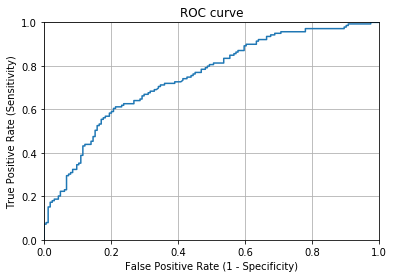

In [27]:
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score


fpr, tpr, thresholds = roc_curve(Y, actual_predicted['Predicted_Prob'].to_numpy())
plt.plot(fpr, tpr)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.title('ROC curve')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.grid(True)

print('ROC-AUC is: '+str(roc_auc_score(Y, actual_predicted['Predicted_Prob'].to_numpy())))

# Naive Bayes Classifier

In [28]:
from sklearn import datasets
from sklearn import metrics
from sklearn.naive_bayes import GaussianNB

# fit a Naive Bayes model to the data
model = GaussianNB()
#### for continuous features

###ALSO TALK ABOUT MultinomialNB() and BernoulliNB()

##MultinomialNB() The multinomial Naive Bayes classifier is suitable for classification with discrete features (e.g., word counts for text classification). The multinomial distribution normally requires integer feature counts. However, in practice, fractional counts such as tf-idf may also work.
##model = MultinomialNB(alpha=3.0)#default value of 1.0


##BernoulliNB() Like MultinomialNB, this classifier is suitable for discrete data. The difference is that while MultinomialNB works with occurrence counts, BernoulliNB is designed for binary/boolean features.
##model = BernoulliNB(alpha=4.0)#default value of 1.0 
  
model.fit(X, Y)
# make predictions
Y_predicted = model.predict(X)
# summarize the fit of the model
print(metrics.classification_report(Y, Y_predicted))
print(metrics.confusion_matrix(Y, Y_predicted))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87       164
           1       0.86      0.81      0.84       139

    accuracy                           0.85       303
   macro avg       0.86      0.85      0.85       303
weighted avg       0.86      0.85      0.85       303

[[146  18]
 [ 26 113]]
